<a href="https://colab.research.google.com/github/swatipai30101998/C02_emission/blob/main/CO2_Emission_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


In [ ]:
(df.isnull().sum())/len(df.index)*100

,0
Make,0.0
Model,0.0
Vehicle Class,0.0
Engine Size(L),0.0
Cylinders,0.0
Transmission,0.0
Fuel Type,0.0
Fuel Consumption City (L/100 km),0.0
Fuel Consumption Hwy (L/100 km),0.0
Fuel Consumption Comb (L/100 km),0.0


#data set is clean, no null values, no need to remove any rows containing null values using pd.isnull or np.isnan

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),CO2_zscore
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,-0.997012
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,-0.493917
2,ACURA,ILX,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,-2.204440
3,ACURA,MDX,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,0.276277
4,ACURA,RDX,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,-0.112095


#from above result, CO2 Emissions(g/km) is a target variable(depenedent variable) and rest are independent variables which will help in making interpretations

#Q1: Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

In [ ]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'CO2_zscore'],
      dtype='object')

In [ ]:
target = 'CO2 Emissions(g/km)'

import numpy as np

independent_variables = np.setdiff1d(df.columns, target)
independent_variables

array(['CO2_zscore', 'Cylinders', 'Engine Size(L)',
       'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Type', 'Make', 'Model',
       'Transmission', 'Vehicle Class'], dtype=object)

#Q2 Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

#To start with, Model column has space separated values, which makes it difficult to identify unique rows, so retain strings before space

In [ ]:
#To start with, Model column has space separated values, which makes it difficult to identify unique rows, so retain strings before space

df['Model'] = df['Model'].apply(lambda x:x.split()[0])
df['Model']

,Model
0,ILX
1,ILX
2,ILX
3,MDX
4,RDX
...,...
7380,XC40
7381,XC60
7382,XC60
7383,XC90


In [ ]:
df['Model'].value_counts()

,count
Model,
911,196
F-150,191
AMG,147
COOPER,118
1500,87
...,...
Cadenza,1
VENENO,1
GranTurismo,1


# check for any null or missing values


In [ ]:
df.isnull().sum()/len(df.index)*100

,0
Make,0.000000
Model,0.000000
Vehicle Class,0.000000
Engine Size(L),0.000000
Cylinders,0.000000
Transmission,0.000000
Fuel Type,0.000000
Fuel Consumption City (L/100 km),0.000000
Fuel Consumption Hwy (L/100 km),0.000000
Fuel Consumption Comb (L/100 km),0.000000


# No null or missing values, Columns like Make, Model, Vehicle CLass may not contribute to interpretation of Co2 emissions so dropping those colums

In [ ]:
master = df.drop(['Make', 'Model', 'Vehicle Class'], axis=1)

#Q3 Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

In [ ]:
master['CO2 Emissions(g/km)'].describe()

,CO2 Emissions(g/km)
count,7385.000000
mean,250.584699
std,58.512679
min,96.000000
25%,208.000000
50%,246.000000
75%,288.000000
max,522.000000


In [ ]:
#correlation matrix helps in determining which feature are most important for making interpretations on co2 emission

In [ ]:
master.head()

,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
#since Fuel Type and Transmission are not numeric attributes, we can use one hot encoding to convert them

In [ ]:
categorical_cols = ['Transmission', 'Fuel Type']

master_encoded = pd.get_dummies(master, columns=categorical_cols, dtype=int, drop_first=True)
master_encoded.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_A4,Transmission_A5,Transmission_A6,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,9.9,6.7,8.5,33,196,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2.4,4,11.2,7.7,9.6,29,221,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,1.5,4,6.0,5.8,5.9,48,136,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,3.5,6,12.7,9.1,11.1,25,255,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,3.5,6,12.1,8.7,10.6,27,244,0,0,0,...,0,0,0,0,0,0,0,0,0,1


#correlation matrix

In [ ]:
corr_matrix = master_encoded.corr()

In [ ]:
corr_matrix

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_A4,Transmission_A5,Transmission_A6,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
Engine Size(L),1.000000,0.927653,0.831379,0.761526,0.817060,-0.757854,0.851145,0.035005,0.082283,0.180285,...,-0.052374,-0.085643,-0.040485,-0.160277,-0.155131,0.046261,0.164828,0.003781,-0.236023,0.186346
Cylinders,0.927653,1.000000,0.800702,0.715252,0.780534,-0.719321,0.832644,0.021429,0.046335,0.103520,...,-0.076331,-0.078310,-0.041885,-0.149358,-0.154826,0.045005,0.118302,0.002451,-0.310360,0.277499
Fuel Consumption City (L/100 km),0.831379,0.800702,1.000000,0.948180,0.993810,-0.927059,0.919592,0.092999,0.082107,0.240401,...,-0.133728,-0.124949,-0.049058,-0.145531,-0.118235,0.014994,0.450996,0.008789,-0.321992,0.160233
Fuel Consumption Hwy (L/100 km),0.761526,0.715252,0.948180,1.000000,0.977299,-0.890638,0.883536,0.138233,0.076236,0.250183,...,-0.083574,-0.106043,-0.023289,-0.128692,-0.151254,-0.004302,0.483037,0.002398,-0.257733,0.084032
Fuel Consumption Comb (L/100 km),0.817060,0.780534,0.993810,0.977299,1.000000,-0.925576,0.918052,0.109781,0.080967,0.247124,...,-0.117963,-0.119910,-0.040648,-0.141211,-0.130877,0.008220,0.467394,0.006940,-0.303291,0.135427
Fuel Consumption Comb (mpg),-0.757854,-0.719321,-0.927059,-0.890638,-0.925576,1.000000,-0.907426,-0.058000,-0.083251,-0.203495,...,0.134484,0.130543,0.032609,0.147897,0.115229,-0.031882,-0.323444,-0.008822,0.309235,-0.205789
CO2 Emissions(g/km),0.851145,0.832644,0.919592,0.883536,0.918052,-0.907426,1.000000,0.068239,0.088082,0.168321,...,-0.126081,-0.125544,-0.041154,-0.154613,-0.117452,0.019191,0.096197,-0.007476,-0.260382,0.231164
Transmission_A4,0.035005,0.021429,0.092999,0.138233,0.109781,-0.058000,0.068239,1.000000,-0.010108,-0.032591,...,-0.011747,-0.012008,-0.006866,-0.015437,-0.035127,-0.010525,0.084685,-0.001097,0.049263,-0.082446
Transmission_A5,0.082283,0.046335,0.082107,0.076236,0.080967,-0.083251,0.088082,-0.010108,1.000000,-0.037098,...,-0.013371,-0.013668,-0.007815,-0.017571,-0.039984,-0.011981,0.004633,-0.001248,0.088454,-0.086116
Transmission_A6,0.180285,0.103520,0.240401,0.250183,0.247124,-0.203495,0.168321,-0.032591,-0.037098,1.000000,...,-0.043113,-0.044072,-0.025200,-0.056657,-0.128926,-0.038631,0.254123,-0.004025,0.125759,-0.253948


In [ ]:
co2_corr = corr_matrix['CO2 Emissions(g/km)'].sort_values(ascending=False)

In [ ]:
co2_corr

,CO2 Emissions(g/km)
CO2 Emissions(g/km),1.000000
Fuel Consumption City (L/100 km),0.919592
Fuel Consumption Comb (L/100 km),0.918052
Fuel Consumption Hwy (L/100 km),0.883536
Engine Size(L),0.851145
Cylinders,0.832644
Fuel Type_Z,0.231164
Transmission_A6,0.168321
Transmission_A8,0.151831
Fuel Type_E,0.096197


In [ ]:
print("Top correlations with CO2 Emissions:\n")
print(co2_corr.head(15))

Top correlations with CO2 Emissions:

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Type_Z                         0.231164
Transmission_A6                     0.168321
Transmission_A8                     0.151831
Fuel Type_E                         0.096197
Transmission_AS8                    0.095415
Transmission_AS7                    0.092683
Transmission_A7                     0.090287
Transmission_A5                     0.088082
Transmission_AS10                   0.081813
Name: CO2 Emissions(g/km), dtype: float64


#Fuel Consumption City and Fuel Consumption Comb (L/100 km) are top 2 columns that are most related to C02 Emissions(g/km) i.e. As one increases, the other increases

#Q4: Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

/tmp/ipython-input-1868217067.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


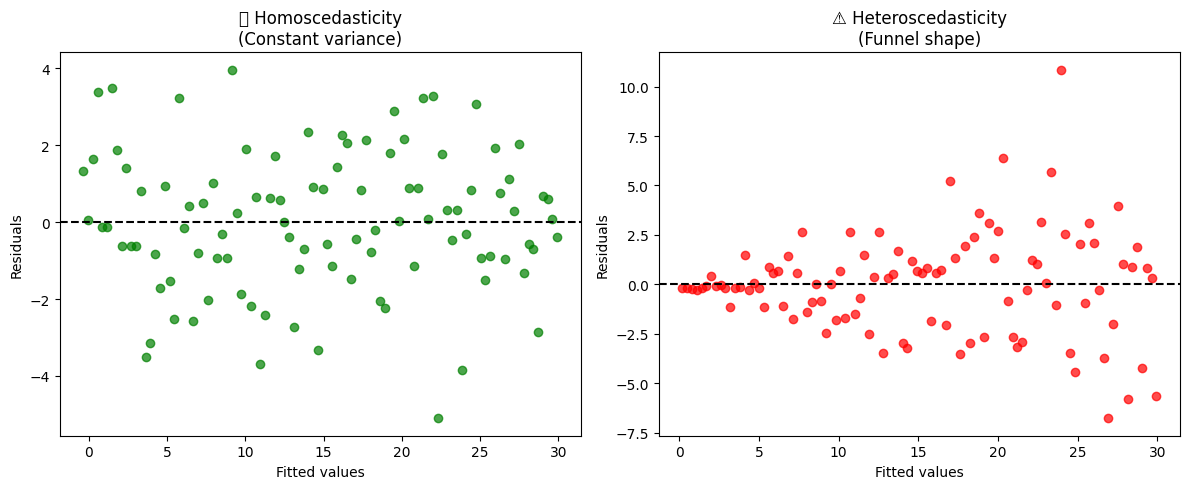

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Homoscedastic data ---
np.random.seed(42)
x1 = np.linspace(0, 10, 100)
y1 = 3*x1 + np.random.normal(0, 2, 100)  # constant variance

# --- Heteroscedastic data ---
x2 = np.linspace(0, 10, 100)
y2 = 3*x2 + np.random.normal(0, 0.5*x2, 100)  # variance increases with x

# --- Fit models ---
model1 = sm.OLS(y1, sm.add_constant(x1)).fit()
model2 = sm.OLS(y2, sm.add_constant(x2)).fit()

# --- Get fitted values and residuals ---
fitted1, resid1 = model1.fittedvalues, model1.resid
fitted2, resid2 = model2.fittedvalues, model2.resid

# --- Plot ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(fitted1, resid1, color='green', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('✅ Homoscedasticity\n(Constant variance)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

plt.subplot(1,2,2)
plt.scatter(fitted2, resid2, color='red', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('⚠️ Heteroscedasticity\n(Funnel shape)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
all_columns = master_encoded.columns

for i in all_columns:
  sns.scatterplot(x=i, y='CO2 Emissions(g/km)', data=master_encoded, alpha=0.7)
  plt.title(f'CO₂ Emissions vs {i}')
  plt.show()

#Q5 Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

In [ ]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)', 'CO2_zscore'],
      dtype='object')

In [ ]:
df['CO2 Emissions(g/km)'].describe()

,CO2 Emissions(g/km)
count,7385.000000
mean,250.584699
std,58.512679
min,96.000000
25%,208.000000
50%,246.000000
75%,288.000000
max,522.000000


# choose mean as a aggregate function, each each vehicle class + fuel type, you get average so that we can check which combination has highest and lowest emissions

In [ ]:
df.groupby(['Vehicle Class', 'Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values(ascending=True)

# for VAN - PASSENGER with Fuel X, CO2 emission is highest
# for SUBCOMPACT with Fuel D, C02 emission is lowest

In [ ]:
df.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].mean().sort_values()

,CO2 Emissions(g/km)
Vehicle Class,
STATION WAGON - SMALL,200.067460
COMPACT,216.679061
MID-SIZE,222.455428
SUV - SMALL,236.292523
MINICOMPACT,236.607362
SPECIAL PURPOSE VEHICLE,237.597403
STATION WAGON - MID-SIZE,238.698113
SUBCOMPACT,246.448845
MINIVAN,262.312500


In [ ]:
df.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().sort_values()

,CO2 Emissions(g/km)
Fuel Type,
N,213.000000
X,235.119329
D,237.548571
Z,266.043410
E,275.091892


# Above 2 results show that Fuel Type does not have much impact on CO 2 emissions as max and min values are approx closer,
# But vehicle type does show much impact as the max and min values range from 200 to 397 which is a huge difference when compared to 213 and 275

#Q6 Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

# To know how far a point is from mean(), we compute z-score, z-score is computed by xi - x.mean()/x.std()
# With this you get to know how far a particlar point is from mean
# Then rows whose z-score > 2 means they are 2 std deviations above mean() and all rows with z-score < -2 means they are 2 std deviations below mean(), and hence can be considered as outliers

# we need to find all those rows which ahev z-score > 2 and < - 2

In [ ]:
df['CO2_zscore'] = df.groupby(['Vehicle Class', 'Fuel Type'])['CO2 Emissions(g/km)'] \
                     .transform(lambda x: (x - x.mean()) / x.std())

# Flag unusual vehicles
unusual_high = df[df['CO2_zscore'] > 2]   # significantly above average
unusual_low = df[df['CO2_zscore'] < -2]   # significantly below average

print(f"High emission outliers: {len(unusual_high)}")
print(f"Low emission outliers: {len(unusual_low)}")

unusual_high[['Make','Model','Vehicle Class','Fuel Type','Engine Size(L)','CO2 Emissions(g/km)','CO2_zscore']].head()

High emission outliers: 266
Low emission outliers: 111


,Make,Model,Vehicle Class,Fuel Type,Engine Size(L),CO2 Emissions(g/km),CO2_zscore
13,ASTON MARTIN,DB9,MINICOMPACT,Z,5.9,359,3.086635
14,ASTON MARTIN,RAPIDE,SUBCOMPACT,Z,5.9,359,2.167289
19,ASTON MARTIN,VANQUISH,MINICOMPACT,Z,5.9,359,3.086635
70,BENTLEY,CONTINENTAL,SUBCOMPACT,Z,6.0,356,2.105997
72,BENTLEY,CONTINENTAL,SUBCOMPACT,Z,6.0,380,2.596336


# Common conclusion which can be derived is that all vehicles with fuel type Z and engine size in 5.9-6 L size range have high co2 emissions

In [ ]:
unusual_low[['Make','Model','Vehicle Class','Fuel Type','Engine Size(L)','CO2 Emissions(g/km)','CO2_zscore']].head()

# Common conclusion which can be derived is that all vehicles with fuel type X and engine size in 1.8-2.5 L size range have low co2 emissions

#Q 7 Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.

In [ ]:
master_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    7385 non-null   float64
 1   Cylinders                         7385 non-null   int64  
 2   Fuel Consumption City (L/100 km)  7385 non-null   float64
 3   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 4   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 5   Fuel Consumption Comb (mpg)       7385 non-null   int64  
 6   CO2 Emissions(g/km)               7385 non-null   int64  
 7   Transmission_A4                   7385 non-null   int64  
 8   Transmission_A5                   7385 non-null   int64  
 9   Transmission_A6                   7385 non-null   int64  
 10  Transmission_A7                   7385 non-null   int64  
 11  Transmission_A8                   7385 non-null   int64  
 12  Transm

In [ ]:
master_encoded.isnull().sum()/len(master_encoded.index)*100

,0
Engine Size(L),0.0
Cylinders,0.0
Fuel Consumption City (L/100 km),0.0
Fuel Consumption Hwy (L/100 km),0.0
Fuel Consumption Comb (L/100 km),0.0
Fuel Consumption Comb (mpg),0.0
CO2 Emissions(g/km),0.0
Transmission_A4,0.0
Transmission_A5,0.0
Transmission_A6,0.0


# All are numerical attributes and there are no Null values

#Checking if all colums are in same range if not Normalizaling using StandardScaler or MinMaxSaler is required

In [ ]:
master_encoded.head(5)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_A4,Transmission_A5,Transmission_A6,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,9.9,6.7,8.5,33,196,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2.4,4,11.2,7.7,9.6,29,221,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,1.5,4,6.0,5.8,5.9,48,136,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,3.5,6,12.7,9.1,11.1,25,255,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,3.5,6,12.1,8.7,10.6,27,244,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Since we have performed one-hot encoding of non-numeric attributes fuel type and transmission, which has converted them into 0 and 1, and other columns are different range, we may have to perform StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = master_encoded.columns
master_encoded[numerical_cols] = scaler.fit_transform(master_encoded[numerical_cols])

In [ ]:
master_encoded

In [ ]:
corr = master_encoded.corr()

In [ ]:
corr['CO2 Emissions(g/km)'].sort_values(ascending=False)

In [ ]:
corr

#Q8 Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Y = master_encoded['CO2 Emissions(g/km)']
X = master_encoded.drop(['CO2 Emissions(g/km)'], axis=1)





In [ ]:
X.shape

(7385, 36)

In [ ]:
Y.shape

(7385,)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape

(5908, 36)

In [ ]:
y_train.shape

(5908,)

In [ ]:
x_test.shape

(1477, 36)

In [ ]:
y_test.shape

(1477,)

In [ ]:
lm = LinearRegression()
lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = lm.predict(x_test)

from sklearn.metrics import r2_score
lm_r2 = r2_score(y_test, y_pred)
print("R-squared:", lm_r2)

R-squared: 0.8966573532673836


In [ ]:
VIF = (1/(1-lm_r2))
print("VIF:", VIF)

VIF: 9.676547210827202


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = master_encoded.drop(['CO2 Emissions(g/km)'], axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False).head(10))

                             Feature           VIF
4   Fuel Consumption Comb (L/100 km)  72070.881137
2   Fuel Consumption City (L/100 km)  29005.280503
3    Fuel Consumption Hwy (L/100 km)  10034.777018
1                          Cylinders     96.697798
0                     Engine Size(L)     67.129079
5        Fuel Consumption Comb (mpg)     57.390153
20                  Transmission_AS6     34.784050
22                  Transmission_AS8     31.235321
30                   Transmission_M6     24.211390
34                       Fuel Type_X     22.684094


#suggests there is multicollinearity, so find if there indepenedent variables that highly co- related

#Q9 Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.
#Q10 Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

In [ ]:
master_encoded_without_co2 = master_encoded.drop(['CO2 Emissions(g/km)'], axis=1)
d = {}
for i in master_encoded_without_co2.columns:
  X = master_encoded_without_co2.drop(i, axis=1)
  Y = master_encoded_without_co2[i]
  x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
  lm = LinearRegression()
  lm.fit(x_train, y_train)
  y_pred = lm.predict(x_test)
  lm_r2 = r2_score(y_test, y_pred)
  #print(i)
  #print(lm_r2)
  d[i] = lm_r2
for i in d:
  if d[i] > 0.95:
    print(f"{i} {d[i]}")

Fuel Consumption City (L/100 km) 0.9995386656596671
Fuel Consumption Hwy (L/100 km) 0.9983721198227405
Fuel Consumption Comb (L/100 km) 0.9997960460520857
Transmission_A6 0.9599127125473523
Transmission_AS6 0.9733025560037324
Transmission_AS8 0.9732120619694408
Transmission_M6 0.9631388173801063


# Drop each indepenedent variable, and compute it's accuracy score with rest independent variables

# This will tell which attribute will have multicollineariry with other independent variables

In [ ]:
corr = master_encoded_without_co2.corr().abs()
high_corr_pairs = corr.unstack().sort_values(ascending=False)
print(high_corr_pairs[high_corr_pairs < 1].head(10))

Fuel Consumption Comb (L/100 km)  Fuel Consumption City (L/100 km)    0.993810
Fuel Consumption City (L/100 km)  Fuel Consumption Comb (L/100 km)    0.993810
Fuel Consumption Comb (L/100 km)  Fuel Consumption Hwy (L/100 km)     0.977299
Fuel Consumption Hwy (L/100 km)   Fuel Consumption Comb (L/100 km)    0.977299
Fuel Consumption City (L/100 km)  Fuel Consumption Hwy (L/100 km)     0.948180
Fuel Consumption Hwy (L/100 km)   Fuel Consumption City (L/100 km)    0.948180
Cylinders                         Engine Size(L)                      0.927653
Engine Size(L)                    Cylinders                           0.927653
Fuel Consumption City (L/100 km)  Fuel Consumption Comb (mpg)         0.927059
Fuel Consumption Comb (mpg)       Fuel Consumption City (L/100 km)    0.927059
dtype: float64


# Drop columns which have same R2 values

In [ ]:
new_master = master_encoded.drop(['Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Engine Size(L)', 'Fuel Consumption City (L/100 km)', 'Transmission_A6', 'Transmission_AS6', 'Transmission_A8', 'Transmission_M6'], axis=1)
Y = new_master['CO2 Emissions(g/km)']
X = new_master.drop(['CO2 Emissions(g/km)'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
lm = LinearRegression()
lm.fit(x_train, y_train)

print(X.columns)
print(lm.coef_)
print(lm.intercept_)
y_pred = lm.predict(x_test)
lm_r2 = r2_score(y_test, y_pred)
print("R-squared:", lm_r2 )

Index(['Cylinders', 'Fuel Consumption Comb (mpg)', 'Transmission_A4',
       'Transmission_A5', 'Transmission_A7', 'Transmission_A9',
       'Transmission_AM5', 'Transmission_AM6', 'Transmission_AM7',
       'Transmission_AM8', 'Transmission_AM9', 'Transmission_AS10',
       'Transmission_AS4', 'Transmission_AS5', 'Transmission_AS7',
       'Transmission_AS8', 'Transmission_AS9', 'Transmission_AV',
       'Transmission_AV10', 'Transmission_AV6', 'Transmission_AV7',
       'Transmission_AV8', 'Transmission_M5', 'Transmission_M7', 'Fuel Type_E',
       'Fuel Type_N', 'Fuel Type_X', 'Fuel Type_Z'],
      dtype='object')
[ 1.04016280e+01 -6.29071843e+00  1.55549053e+01  4.17147181e+00
  3.87977725e+00 -6.48239463e+00  2.48103123e+01  1.70495463e+01
 -1.27080393e+00 -1.18062041e+01 -3.98214410e+00 -4.10815970e-01
 -1.37267222e+00  3.29164867e+00 -5.19704162e+00 -3.53817188e+00
 -5.47982020e+00  1.23661843e+01 -1.31973297e+01 -3.13287202e+00
 -1.92004157e+00 -3.64621643e+00  1.04258291e+00 -

In [ ]:
VIF = (1/(1-lm_r2))
print("VIF:", VIF)

VIF: 13.318894839427553


#VIF reduced from 103 to 13 which means collinearity is significantly reduced

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[['Engine Size(L)', 'Fuel Consumption City (L/100 km)',
        'Fuel Consumption Hwy (L/100 km)', 'Transmission', 'Fuel Type', 'Vehicle Class']]

# One-hot encode if needed
X = pd.get_dummies(X, drop_first=True, dtype=int)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif.sort_values(by="VIF", ascending=False))

                                   Feature         VIF
2          Fuel Consumption Hwy (L/100 km)  378.631489
1         Fuel Consumption City (L/100 km)  335.187054
0                           Engine Size(L)   35.008769
31                             Fuel Type_X   23.023761
32                             Fuel Type_Z   22.281188
17                        Transmission_AS6   12.519846
19                        Transmission_AS8   10.780700
27                         Transmission_M6    8.521311
5                          Transmission_A6    7.624135
11                        Transmission_AM7    5.242468
29                             Fuel Type_E    4.849605
7                          Transmission_A8    4.849165
8                          Transmission_A9    3.789996
18                        Transmission_AS7    3.718090
21                         Transmission_AV    3.441812
38   Vehicle Class_PICKUP TRUCK - STANDARD    3.101204
43               Vehicle Class_SUV - SMALL    2.943066
44        

Model Performance Assessment (Q9)
The linear regression model achieved an R-squared score of 0.9249 after addressing multicollinearity.

R-squared: An R-squared value of 0.9249 indicates that approximately 92.5% of the variance in CO₂ emissions can be explained by the independent variables included in the model. This is a high R-squared value, suggesting that the model fits the data well and is reliable in predicting CO₂ emissions based on the selected features.

VIF: The Variance Inflation Factor (VIF) was reduced from over 100 to around 13 after removing highly correlated features. A lower VIF indicates less multicollinearity among the independent variables, which improves the stability and interpretability of the model coefficients.

Overall, the model performs very well in estimating CO₂ emissions, and the reduction in VIF suggests that the chosen features are not excessively correlated, leading to more reliable coefficient estimates.

Gemini
Factors Influencing CO₂ Emissions and Emission Reduction Suggestions (Q10)
Based on the correlation analysis and the linear regression model, the factors that most strongly influence CO₂ emissions are:

Fuel Consumption: Both city and highway fuel consumption (L/100 km) have a very strong positive correlation with CO₂ emissions. This is expected, as burning more fuel directly leads to higher CO₂ output. Fuel Consumption Comb (mpg) has a strong negative correlation, meaning higher MPG (better fuel efficiency) results in lower CO2 emissions.
Engine Size (L) and Cylinders: These factors are highly correlated with each other and show a strong positive correlation with CO₂ emissions. Larger engines and more cylinders generally consume more fuel, leading to higher emissions.
Fuel Type: While not as strong as fuel consumption or engine characteristics, the fuel type also influences emissions. Fuel Type Z (likely premium gasoline) shows a positive correlation, while Fuel Type X (likely regular gasoline) shows a negative correlation with CO₂ emissions. This suggests that the composition and energy density of the fuel play a role.
Transmission: Some transmission types (e.g., Automatic 6-speed, Automatic 8-speed) show moderate positive correlations with CO₂ emissions, while others (e.g., Manual 5-speed, Manual 6-speed) show negative correlations. This could be due to differences in efficiency and how the transmission manages engine power and fuel delivery.
Vehicle Class: As observed in the grouped analysis, vehicle class has a significant impact on CO2 emissions, with larger vehicles like vans and standard SUVs generally having higher emissions compared to smaller vehicles like compact cars and small station wagons.
Suggestions for Emission Reduction Efforts:

Promote Fuel Efficiency: Encouraging the production and adoption of vehicles with higher fuel efficiency (lower L/100 km and higher mpg) is crucial. This can be achieved through stricter fuel economy standards, incentives for purchasing fuel-efficient vehicles, and public awareness campaigns.
Downsize Engines: Promoting smaller engine sizes and fewer cylinders can directly contribute to lower emissions, especially for vehicles where performance is not a primary concern.
Optimize Transmission Technology: Further research and development in transmission technologies can lead to more efficient power transfer and reduced fuel consumption.
Shift to Lower-Emission Fuel Types: While the impact of fuel type is less significant than other factors, promoting the use of fuels with lower carbon content or alternative fuels can contribute to emission reduction.
Encourage Smaller Vehicle Classes: Promoting the use of smaller and lighter vehicle classes, especially for urban commuting, can significantly reduce overall emissions.
Invest in Alternative Powertrains: The analysis focuses on traditional internal combustion engines. Accelerating the transition to electric vehicles, hydrogen fuel cell vehicles, and other zero-emission technologies is essential for long-term emission reduction goals.
Address Outliers: Investigating the "unusual high" emission vehicles identified in the analysis can help identify specific models or technologies that are contributing disproportionately to emissions and require targeted interventions.
